# Model 2: Contextual Bandit for Retention Action Selection

This notebook implements the contextual-bandit model described in **Section 4** of the methodology report and demonstrates learning following the **Section 7** proof-of-concept protocol.

**Architecture:**
- Ridge reward model per action: $\hat{\mu}_a(x) = \theta_a^\top x$
- Cumulative closed-form refit each month
- $\varepsilon$-greedy exploration with decay
- Actions: $\mathcal{A} = \{\text{no\_action},\; \text{push\_notification},\; \text{email},\; \text{call}\}$
- Reward (EUR): $R_i = (1 - Y_i)\,v_i - c(A_i)$ where $v_i$ is annual customer revenue

**Key demonstration goal:**
- All 4 actions are available from month 1 — the model starts knowing nothing.
- Over 24 months, the model learns **which action is best for each customer** based on accumulated data.
- We track cumulative **revenue saved** (EUR) vs the no-action baseline to show the business impact.

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import defaultdict

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

SEED = 42
np.random.seed(SEED)

## 1. Load and prepare the bandit training dataset

In [89]:
df = pd.read_csv("../data/output/bandit_training_dataset.csv")
df["reference_date"] = pd.to_datetime(df["reference_date"])
df = df.sort_values(["reference_date", "client_id"]).reset_index(drop=True)

print(f"Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Date range: {df['reference_date'].min().date()} → {df['reference_date'].max().date()}")
print(f"Unique customers: {df['client_id'].nunique():,}")
print(f"Monthly batches: {df['reference_date'].nunique()}")

Dataset: 65,544 rows, 32 columns
Date range: 2024-01-01 → 2025-12-01
Unique customers: 7,805
Monthly batches: 24


In [90]:
# Feature columns used as context vector x_i
FEATURE_COLS = [
    "tenure_years", "n_products", "has_loan", "receives_salary",
    "avg_txn_per_month", "avg_txn_amount", "txn_trend",
    "avg_balance", "balance_trend", "n_contacts",
    "age", "credit_rating", "has_deposit", "digital_txn_ratio",
    "debit_credit_ratio", "balance_volatility", "txn_amount_std",
    "recency_days", "n_complaint_contacts", "avg_product_age_years",
]

ACTIONS = ["no_action", "push_notification", "email", "call"]
ACTION_TO_IDX = {a: i for i, a in enumerate(ACTIONS)}
ACTION_COSTS = {"no_action": 0.0, "push_notification": 20.0, "email": 100.0, "call": 1200.0}
N_ACTIONS = len(ACTIONS)

# Ground-truth expected reward columns (from data generation)
ER_COLS = ["er_no_action", "er_push_notification", "er_email", "er_call"]

print(f"Features (d={len(FEATURE_COLS)}): {FEATURE_COLS[:5]} ... {FEATURE_COLS[-3:]}")
print(f"Actions: {ACTIONS}")
print(f"Costs (EUR): {ACTION_COSTS}")

# Verify ground truth columns exist
assert all(c in df.columns for c in ER_COLS), "Missing expected reward columns"
print(f"\nGround-truth expected rewards available for exact counterfactual evaluation ✓")

# Show risk-value correlation
corr = df[["churn_risk_score", "customer_value_score"]].corr().iloc[0, 1]
print(f"Risk-Value correlation: {corr:.3f}")

# Action distribution in logged data
print(f"\nLogged action distribution:")
print(df["action"].value_counts().to_string())
print(f"Call observations: {(df['action']=='call').sum():,} / {len(df):,} ({(df['action']=='call').mean():.1%})")

Features (d=20): ['tenure_years', 'n_products', 'has_loan', 'receives_salary', 'avg_txn_per_month'] ... ['recency_days', 'n_complaint_contacts', 'avg_product_age_years']
Actions: ['no_action', 'push_notification', 'email', 'call']
Costs (EUR): {'no_action': 0.0, 'push_notification': 20.0, 'email': 100.0, 'call': 1200.0}

Ground-truth expected rewards available for exact counterfactual evaluation ✓
Risk-Value correlation: -0.303

Logged action distribution:
action
email                22552
call                 15261
push_notification    14598
no_action            13133
Call observations: 15,261 / 65,544 (23.3%)


In [91]:
# Standardize base features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_base = scaler.fit_transform(df[FEATURE_COLS].values)

# Add derived features that are critical for the bandit's decision:
# churn_risk_score, customer_value_score, and their interaction
# These directly capture WHEN calls are worthwhile (high risk × high value)
risk = df["churn_risk_score"].values.reshape(-1, 1)
value = df["customer_value_score"].values.reshape(-1, 1)
risk_x_value = (risk * value)  # key interaction

# Standardize the derived features too
derived = np.hstack([risk, value, risk_x_value])
scaler_derived = StandardScaler()
X_derived = scaler_derived.fit_transform(derived)

# Combine: [bias, base_features, risk, value, risk×value]
X_all = np.hstack([np.ones((X_base.shape[0], 1)), X_base, X_derived])
d = X_all.shape[1]
print(f"Context dimension: d = {d}  (1 bias + {len(FEATURE_COLS)} features + 3 derived)")

Context dimension: d = 24  (1 bias + 20 features + 3 derived)


## 2. Contextual Bandit Implementation

Linear reward model per action with cumulative Ridge regression and **cost-aware regularization**, as described in Sections 4–7 of the report.

In [92]:
class RidgeContextualBandit:
    """
    Contextual bandit with Ridge regression per action and ε-greedy exploration.
    
    Per-action reward model:  μ̂_a(x) = θ_a^T x
    Trained via Ridge (closed-form) on cumulative data, refitted each month.
    
    Cost-aware regularization: α_a = α_base + cost_reg_scale × cost(a).
    Expensive actions (calls) get stronger L2 penalty initially, requiring
    more evidence before they are recommended. This decays each month.
    """
    
    def __init__(self, n_actions, d, alpha=1.0, epsilon=0.25,
                 epsilon_decay=0.97, epsilon_min=0.02,
                 action_costs=None, cost_reg_scale=0.0, cost_reg_decay=0.85):
        self.n_actions = n_actions
        self.d = d
        self.alpha = alpha
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        
        # Cost-aware regularization
        self.action_costs = action_costs if action_costs is not None else [0.0] * n_actions
        self.cost_reg_scale = cost_reg_scale
        self.cost_reg_decay = cost_reg_decay
        
        # Per-action parameter vectors
        self.theta = np.zeros((n_actions, d))
        
        # Cumulative sufficient statistics: X^T X and X^T r for each action
        self.XtX = [np.zeros((d, d)) for _ in range(n_actions)]
        self.Xtr = [np.zeros(d) for _ in range(n_actions)]
        self.n_samples = np.zeros(n_actions, dtype=int)
    
    def add_batch(self, X_batch, actions, rewards):
        """Add a batch of observations and update sufficient statistics."""
        for a in range(self.n_actions):
            mask = actions == a
            if mask.sum() == 0:
                continue
            Xa = X_batch[mask]
            ra = rewards[mask]
            self.XtX[a] += Xa.T @ Xa
            self.Xtr[a] += Xa.T @ ra
            self.n_samples[a] += mask.sum()
    
    def refit(self):
        """Refit Ridge for each action with cost-aware regularization."""
        for a in range(self.n_actions):
            if self.n_samples[a] >= self.d:
                # Cost-proportional regularization: expensive actions need more evidence
                alpha_a = self.alpha + self.cost_reg_scale * self.action_costs[a]
                A = self.XtX[a] + alpha_a * np.eye(self.d)
                self.theta[a] = np.linalg.solve(A, self.Xtr[a])
    
    def predict_rewards(self, x):
        """Predict expected reward for each action given context x."""
        return self.theta @ x
    
    def select_action(self, x, explore=True):
        """ε-greedy action selection."""
        if explore and np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.predict_rewards(x)))
    
    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
    
    def decay_cost_reg(self):
        """Decay cost regularization — lets the model trust expensive actions more over time."""
        self.cost_reg_scale *= self.cost_reg_decay

print("RidgeContextualBandit defined ✓ (with cost-aware regularization)")

RidgeContextualBandit defined ✓ (with cost-aware regularization)


## 3. Time-ordered training loop

We process the dataset **chronologically by monthly batch**, simulating the operational pipeline:
1. For each month: add observed (action, reward) pairs to cumulative data, refit Ridge
2. After refit: evaluate current policy using **ground-truth expected rewards**  
3. Ground truth: dataset contains $E[R(a)] = (1-p(a)) \cdot v - c(a)$ for all actions (in EUR)
4. This gives us exact counterfactual evaluation — no need for matched/IPS estimation

All 4 actions are available from month 1 — we track how the model gradually learns.

In [93]:
# ── Hyperparameters ──
ALPHA = 1.0              # Ridge base regularization
EPSILON_START = 0.25
EPSILON_DECAY = 0.90     # per month (faster decay = less exploration)
EPSILON_MIN = 0.02

# Cost-aware regularization: expensive actions (calls €1,200) are suppressed
# initially and gradually "unlock" as the model gathers evidence they work.
COST_REG_SCALE = 3.0     # initial cost regularization multiplier
COST_REG_DECAY = 0.80    # monthly decay rate

# Bank scale for revenue projection
BANK_ACCOUNTS = 500_000  # target: Croatian bank with 500k open accounts

# Initialize the bandit
bandit = RidgeContextualBandit(
    n_actions=N_ACTIONS,
    d=d,
    alpha=ALPHA,
    epsilon=EPSILON_START,
    epsilon_decay=EPSILON_DECAY,
    epsilon_min=EPSILON_MIN,
    action_costs=[ACTION_COSTS[a] for a in ACTIONS],
    cost_reg_scale=COST_REG_SCALE,
    cost_reg_decay=COST_REG_DECAY,
)

# ── Metrics storage ──
monthly_metrics = []
theta_history = []

# Monthly batches in chronological order
months = sorted(df["reference_date"].unique())
print(f"Training: 1 pass × {len(months)} months (cumulative Ridge refit each month)")
print(f"  α={ALPHA}, ε₀={EPSILON_START}, ε_decay={EPSILON_DECAY}")
print(f"  Cost-aware reg: scale₀={COST_REG_SCALE}, decay={COST_REG_DECAY}")
print(f"  → α_call month 0 = {ALPHA + COST_REG_SCALE * ACTION_COSTS['call']:,.0f}  "
      f"(calls suppressed until evidence accumulates)")
print(f"  Bank projection: {BANK_ACCOUNTS:,} accounts")
print("=" * 80)

Training: 1 pass × 24 months (cumulative Ridge refit each month)
  α=1.0, ε₀=0.25, ε_decay=0.9
  Cost-aware reg: scale₀=3.0, decay=0.8
  → α_call month 0 = 3,601  (calls suppressed until evidence accumulates)
  Bank projection: 500,000 accounts


In [94]:
# Ground-truth expected rewards matrix for evaluation
ER_matrix = df[ER_COLS].values  # shape (N, 4)

# Pre-compute GLOBAL value deciles for tracking call frequency by customer segment
df["value_decile_global"] = pd.qcut(df["customer_value_score"], 10,
                                     labels=[f"D{i}" for i in range(1, 11)])
TRACKED_DECILES = ["D1", "D5", "D10"]

# Cumulative revenue tracking
cumul_policy_revenue = 0.0
cumul_noaction_revenue = 0.0
cumul_customers = 0

for month_idx, month in enumerate(months):
    batch_mask = df["reference_date"] == month
    batch_indices = df.index[batch_mask].values
    n_batch = len(batch_indices)
    
    # ── Add this month's logged data to the model ──
    X_batch = X_all[batch_indices]
    a_batch = np.array([ACTION_TO_IDX[a] for a in df.loc[batch_indices, "action"]])
    r_batch = df.loc[batch_indices, "reward"].values
    
    bandit.add_batch(X_batch, a_batch, r_batch)
    bandit.refit()
    
    eps_before = bandit.epsilon
    cost_reg_before = bandit.cost_reg_scale
    bandit.decay_epsilon()
    bandit.decay_cost_reg()
    
    # ── Evaluate: use ground-truth expected rewards ──
    policy_actions = np.array([
        int(np.argmax(bandit.predict_rewards(X_all[idx])))
        for idx in batch_indices
    ])
    
    # Ground-truth E[R] of the policy's chosen actions
    policy_er = np.array([
        ER_matrix[idx, policy_actions[j]]
        for j, idx in enumerate(batch_indices)
    ])
    avg_policy_er = policy_er.mean()
    
    # Compare to no-action baseline on same batch
    noaction_er = np.array([ER_matrix[idx, 0] for idx in batch_indices])
    avg_noaction_er = noaction_er.mean()
    
    # Revenue tracking (EUR)
    monthly_revenue_policy = policy_er.sum()
    monthly_revenue_noaction = noaction_er.sum()
    monthly_revenue_saved = monthly_revenue_policy - monthly_revenue_noaction
    
    cumul_policy_revenue += monthly_revenue_policy
    cumul_noaction_revenue += monthly_revenue_noaction
    cumul_customers += n_batch
    
    # Action distribution
    action_counts = np.bincount(policy_actions, minlength=N_ACTIONS)
    action_fracs = action_counts / n_batch
    
    # Parameter norms
    theta_norms = [np.linalg.norm(bandit.theta[a]) for a in range(N_ACTIONS)]
    theta_history.append(theta_norms.copy())
    
    metrics = {
        "batch": month_idx,
        "month": pd.Timestamp(month),
        "month_idx": month_idx,
        "n_batch": n_batch,
        "epsilon": eps_before,
        "cost_reg_scale": cost_reg_before,
        "alpha_call": ALPHA + cost_reg_before * ACTION_COSTS["call"],
        "policy_er": avg_policy_er,
        "noaction_er": avg_noaction_er,
        "improvement_vs_noaction": avg_policy_er - avg_noaction_er,
        "monthly_revenue_saved": monthly_revenue_saved,
        "cumul_revenue_saved": cumul_policy_revenue - cumul_noaction_revenue,
        "cumul_customers": cumul_customers,
    }
    for a_idx, a_name in enumerate(ACTIONS):
        metrics[f"frac_{a_name}"] = action_fracs[a_idx]
        metrics[f"theta_norm_{a_name}"] = theta_norms[a_idx]
    
    # Track call frequency by value decile (D1=lowest, D10=highest)
    batch_vd = df.loc[batch_indices, "value_decile_global"].values
    for vd in TRACKED_DECILES:
        vd_mask = batch_vd == vd
        metrics[f"call_frac_{vd}"] = (policy_actions[vd_mask] == 3).mean() if vd_mask.sum() > 0 else 0.0
    
    monthly_metrics.append(metrics)
    
    # Print progress
    month_str = pd.Timestamp(month).strftime("%Y-%m")
    improvement = avg_policy_er - avg_noaction_er
    alpha_call = ALPHA + cost_reg_before * ACTION_COSTS["call"]
    print(
        f"  {month_str}  |  "
        f"ε={eps_before:.3f}  "
        f"α_call={alpha_call:>6,.0f}  "
        f"E[R]=€{avg_policy_er:,.0f}  "
        f"Δ=€{improvement:+,.0f}  "
        f"no={action_fracs[0]:.2f} pu={action_fracs[1]:.2f} "
        f"em={action_fracs[2]:.2f} ca={action_fracs[3]:.2f}"
    )

print(f"\n{'='*80}")
print(f"Training complete. {len(months)} months, {cumul_customers:,} customer-months.")
print(f"Cumulative revenue saved vs no_action: €{cumul_policy_revenue - cumul_noaction_revenue:,.0f}")
print(f"Final samples per action: {dict(zip(ACTIONS, bandit.n_samples.astype(int)))}")

  2024-01  |  ε=0.250  α_call= 3,601  E[R]=€3,642  Δ=€+33  no=0.60 pu=0.37 em=0.02 ca=0.00
  2024-02  |  ε=0.225  α_call= 2,881  E[R]=€3,662  Δ=€+48  no=0.48 pu=0.40 em=0.11 ca=0.00
  2024-03  |  ε=0.203  α_call= 2,305  E[R]=€3,831  Δ=€+103  no=0.33 pu=0.34 em=0.31 ca=0.02
  2024-04  |  ε=0.182  α_call= 1,844  E[R]=€3,665  Δ=€+119  no=0.25 pu=0.43 em=0.29 ca=0.03
  2024-05  |  ε=0.164  α_call= 1,476  E[R]=€4,153  Δ=€+243  no=0.14 pu=0.42 em=0.33 ca=0.11
  2024-06  |  ε=0.148  α_call= 1,181  E[R]=€3,933  Δ=€+250  no=0.10 pu=0.35 em=0.42 ca=0.13
  2024-07  |  ε=0.133  α_call=   945  E[R]=€3,893  Δ=€+247  no=0.09 pu=0.36 em=0.39 ca=0.16
  2024-08  |  ε=0.120  α_call=   756  E[R]=€4,039  Δ=€+292  no=0.08 pu=0.35 em=0.38 ca=0.19


  2024-09  |  ε=0.108  α_call=   605  E[R]=€3,978  Δ=€+289  no=0.09 pu=0.31 em=0.39 ca=0.21
  2024-10  |  ε=0.097  α_call=   484  E[R]=€4,012  Δ=€+278  no=0.11 pu=0.34 em=0.34 ca=0.21
  2024-11  |  ε=0.087  α_call=   388  E[R]=€3,689  Δ=€+246  no=0.12 pu=0.29 em=0.40 ca=0.20
  2024-12  |  ε=0.078  α_call=   310  E[R]=€3,916  Δ=€+276  no=0.12 pu=0.28 em=0.38 ca=0.22
  2025-01  |  ε=0.071  α_call=   248  E[R]=€3,979  Δ=€+304  no=0.12 pu=0.29 em=0.35 ca=0.24
  2025-02  |  ε=0.064  α_call=   199  E[R]=€4,165  Δ=€+316  no=0.12 pu=0.27 em=0.36 ca=0.25
  2025-03  |  ε=0.057  α_call=   159  E[R]=€4,034  Δ=€+307  no=0.07 pu=0.31 em=0.37 ca=0.25
  2025-04  |  ε=0.051  α_call=   128  E[R]=€4,040  Δ=€+290  no=0.08 pu=0.31 em=0.37 ca=0.23
  2025-05  |  ε=0.046  α_call=   102  E[R]=€4,313  Δ=€+367  no=0.07 pu=0.30 em=0.35 ca=0.28
  2025-06  |  ε=0.042  α_call=    82  E[R]=€4,192  Δ=€+320  no=0.09 pu=0.31 em=0.34 ca=0.26
  2025-07  |  ε=0.038  α_call=    66  E[R]=€4,058  Δ=€+311  no=0.11 pu=0.29 em=0

In [95]:
mdf = pd.DataFrame(monthly_metrics)
mdf.head()

,batch,month,month_idx,n_batch,epsilon,cost_reg_scale,alpha_call,policy_er,noaction_er,improvement_vs_noaction,...,theta_norm_no_action,frac_push_notification,theta_norm_push_notification,frac_email,theta_norm_email,frac_call,theta_norm_call,call_frac_D1,call_frac_D5,call_frac_D10
0,0,2024-01-01,0,2731,0.250000,3.0000,3601.00,3642.002228,3609.218408,32.783821,...,5883.650159,0.374588,3962.057110,0.019407,3157.827414,0.002929,543.974915,0.023810,0.000000,0.000000
1,1,2024-02-01,1,2731,0.225000,2.4000,2881.00,3661.804168,3613.632150,48.172018,...,4834.413205,0.403881,4153.944280,0.108385,3765.781418,0.004394,1145.208978,0.000000,0.003300,0.011450
2,2,2024-03-01,2,2731,0.202500,1.9200,2305.00,3830.668478,3727.294600,103.373878,...,4457.752386,0.343464,4376.116656,0.312340,4073.791028,0.016477,1751.478371,0.003802,0.018868,0.042553
3,3,2024-04-01,3,2731,0.182250,1.5360,1844.20,3664.643531,3546.034935,118.608596,...,4535.700481,0.431344,4537.972557,0.286342,4259.556322,0.034053,2249.002957,0.000000,0.032680,0.041860
4,4,2024-05-01,4,2731,0.164025,1.2288,1475.56,4153.340505,3909.890604,243.449901,...,4595.482243,0.421091,4628.962903,0.329550,4411.958897,0.108751,2691.832063,0.004444,0.083665,0.063187


In [96]:
# ── Quick sanity check ──
early = mdf[mdf["month_idx"] < 6]
late = mdf[mdf["month_idx"] >= 18]
cols = ["policy_er", "noaction_er", "improvement_vs_noaction", "frac_call"]
print(f"First 6 months:  {early[cols].mean().round(1).to_dict()}")
print(f"Last 6 months:   {late[cols].mean().round(1).to_dict()}")
print(f"\nCall fraction: {early['frac_call'].mean():.3f} → {late['frac_call'].mean():.3f}")
print(f"α_call:        {early['alpha_call'].mean():,.0f} → {late['alpha_call'].mean():,.0f}")
print(f"Improvement:   €{early['improvement_vs_noaction'].mean():,.0f} → €{late['improvement_vs_noaction'].mean():,.0f}")
print(f"Cumul rev saved: €{mdf['cumul_revenue_saved'].iloc[-1]:,.0f}")

# Call frequency by value decile (early vs late)
for vd in TRACKED_DECILES:
    e = early[f"call_frac_{vd}"].mean()
    l = late[f"call_frac_{vd}"].mean()
    print(f"  {vd} call freq: {e:.1%} → {l:.1%}")

# Final model predictions vs truth for representative customers
hr_hv = (df["churn_risk_score"] > df["churn_risk_score"].quantile(0.8)) & \
        (df["customer_value_score"] > df["customer_value_score"].quantile(0.8))
print("\nHIGH risk + HIGH value (should select CALL):")
for idx in df[hr_hv].sample(2, random_state=42).index:
    pred = bandit.predict_rewards(X_all[idx])
    true = ER_matrix[idx]
    print(f"  pred: no=€{pred[0]:,.0f} push=€{pred[1]:,.0f} email=€{pred[2]:,.0f} call=€{pred[3]:,.0f} → {ACTIONS[np.argmax(pred)]}")
    print(f"  true: no=€{true[0]:,.0f} push=€{true[1]:,.0f} email=€{true[2]:,.0f} call=€{true[3]:,.0f} → {ACTIONS[np.argmax(true)]}")

First 6 months:  {'policy_er': 3814.3, 'noaction_er': 3681.5, 'improvement_vs_noaction': 132.8, 'frac_call': 0.0}
Last 6 months:   {'policy_er': 3938.9, 'noaction_er': 3648.1, 'improvement_vs_noaction': 290.8, 'frac_call': 0.2}

Call fraction: 0.050 → 0.250
α_call:        2,215 → 41
Improvement:   €133 → €291
Cumul rev saved: €16,588,031
  D1 call freq: 0.5% → 0.0%
  D5 call freq: 5.3% → 37.1%
  D10 call freq: 3.7% → 24.9%

HIGH risk + HIGH value (should select CALL):
  pred: no=€2,052 push=€2,697 email=€3,430 call=€5,932 → call
  true: no=€2,398 push=€2,718 email=€3,320 call=€5,969 → call
  pred: no=€2,013 push=€2,469 email=€2,830 call=€4,411 → call
  true: no=€2,024 push=€2,265 email=€2,707 call=€4,479 → call


## 4. Visualization: Learning Progression

### 4.1 How the model learns: from conservative to targeted

The model starts knowing nothing — expensive actions (calls, €500) are suppressed by cost-aware regularization. Over 24 months it discovers:
1. **Push/email emerge first** — cheap, quickly justified by data
2. **Calls emerge later** — expensive, but highly effective for high-value customers
3. **Targeting sharpens** — calls concentrate on high-value segments (D8–D10)

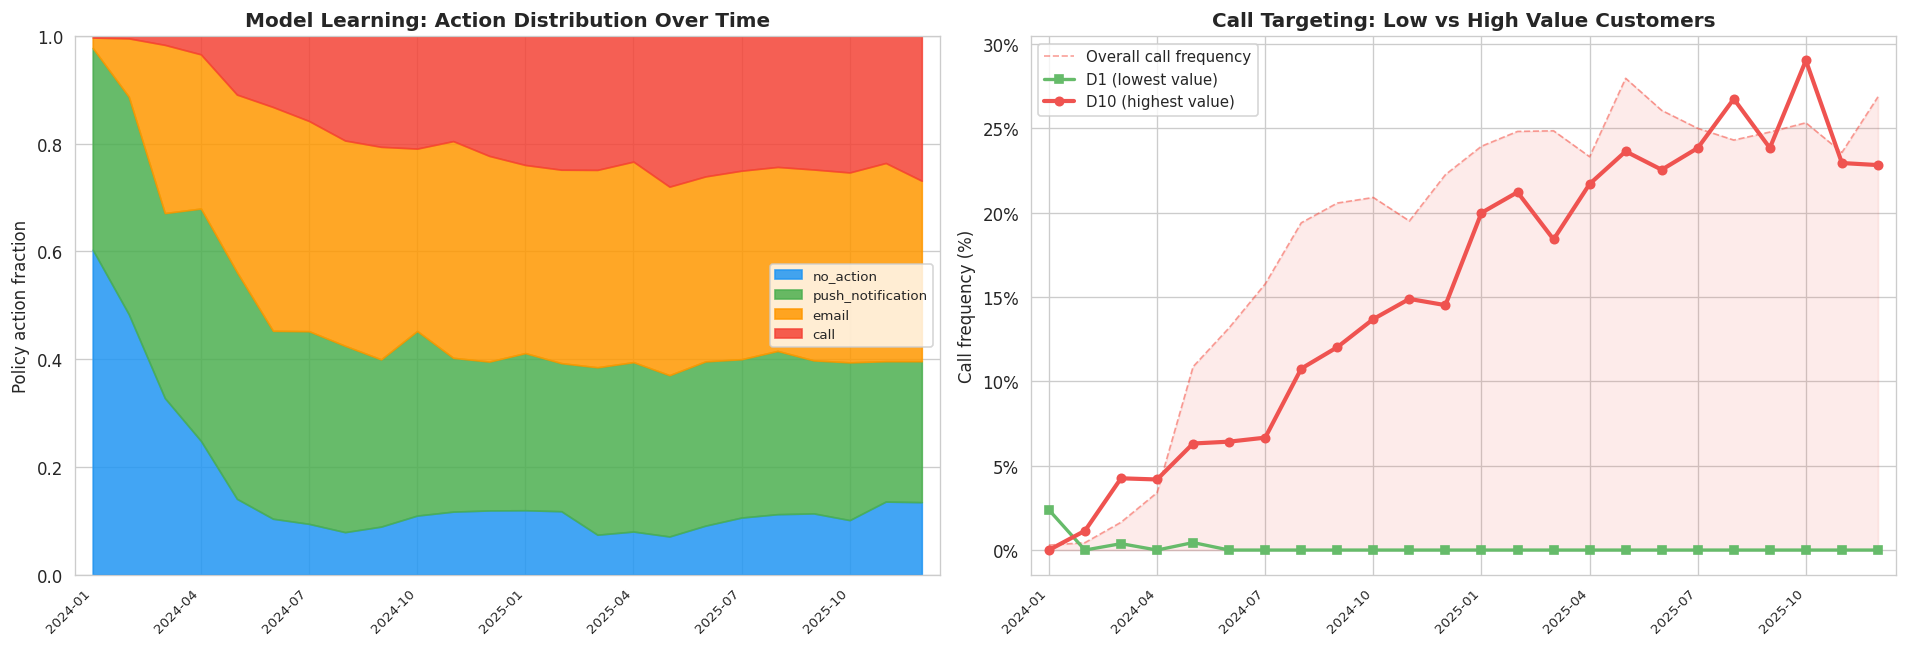

Overall call frequency: months 1-6 = 5.0%, months 19-24 = 25.0%
  D1  (lowest value):  2.4% → 0.0%
  D10 (highest value): 0.0% → 22.8%


In [97]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

action_colors = {"no_action": "#2196F3", "push_notification": "#4CAF50",
                 "email": "#FF9800", "call": "#F44336"}

month_labels = [pd.Timestamp(r.month).strftime("%Y-%m") for _, r in mdf.iterrows()]
tick_step = 3

# ── Left: Stacked area — policy action mix over time ──
ax = axes[0]
x = np.arange(len(mdf))
bottom = np.zeros(len(mdf))
for a_name in ACTIONS:
    vals = mdf[f"frac_{a_name}"].values
    ax.fill_between(x, bottom, bottom + vals, color=action_colors[a_name],
                    alpha=0.85, label=a_name)
    bottom += vals

ax.set_xticks(range(0, len(mdf), tick_step))
ax.set_xticklabels([month_labels[i] for i in range(0, len(mdf), tick_step)],
                   rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Policy action fraction")
ax.set_title("Model Learning: Action Distribution Over Time", fontweight="bold")
ax.legend(loc="center right", fontsize=8)
ax.set_ylim(0, 1.0)
ax.set_xlim(-0.5, len(mdf) - 0.5)

# ── Right: Call frequency D1 (lowest) vs D10 (highest) value ──
ax2 = axes[1]

# Also show overall call frequency as shaded background
overall_call = mdf["frac_call"].values * 100
ax2.fill_between(range(len(mdf)), 0, overall_call, alpha=0.10, color="#F44336")
ax2.plot(range(len(mdf)), overall_call, "--", color="#F44336", linewidth=1, alpha=0.5,
         label="Overall call frequency")

# D1 and D10 lines
ax2.plot(range(len(mdf)), mdf["call_frac_D1"].values * 100, "s-",
         color="#66BB6A", markersize=5, linewidth=2,
         label="D1 (lowest value)")
ax2.plot(range(len(mdf)), mdf["call_frac_D10"].values * 100, "o-",
         color="#EF5350", markersize=5, linewidth=2.5,
         label="D10 (highest value)")

ax2.set_xticks(range(0, len(mdf), tick_step))
ax2.set_xticklabels([month_labels[i] for i in range(0, len(mdf), tick_step)],
                    rotation=45, ha="right", fontsize=8)
ax2.set_ylabel("Call frequency (%)")
ax2.set_title("Call Targeting: Low vs High Value Customers", fontweight="bold")
ax2.legend(fontsize=9, loc="upper left")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax2.set_xlim(-0.5, len(mdf) - 0.5)

plt.tight_layout()
plt.savefig("../data/output/bandit_learning_progression.png", dpi=150, bbox_inches="tight")
plt.show()

# Print key numbers
early_call = mdf[mdf["month_idx"] < 6]["frac_call"].mean()
late_call = mdf[mdf["month_idx"] >= 18]["frac_call"].mean()
print(f"Overall call frequency: months 1-6 = {early_call:.1%}, months 19-24 = {late_call:.1%}")
print(f"  D1  (lowest value):  {mdf['call_frac_D1'].iloc[0]:.1%} → {mdf['call_frac_D1'].iloc[-1]:.1%}")
print(f"  D10 (highest value): {mdf['call_frac_D10'].iloc[0]:.1%} → {mdf['call_frac_D10'].iloc[-1]:.1%}")

### 4.2 Revenue impact and production projection

Expected reward improvement and cumulative revenue saved, projected to a bank with 500,000 accounts.

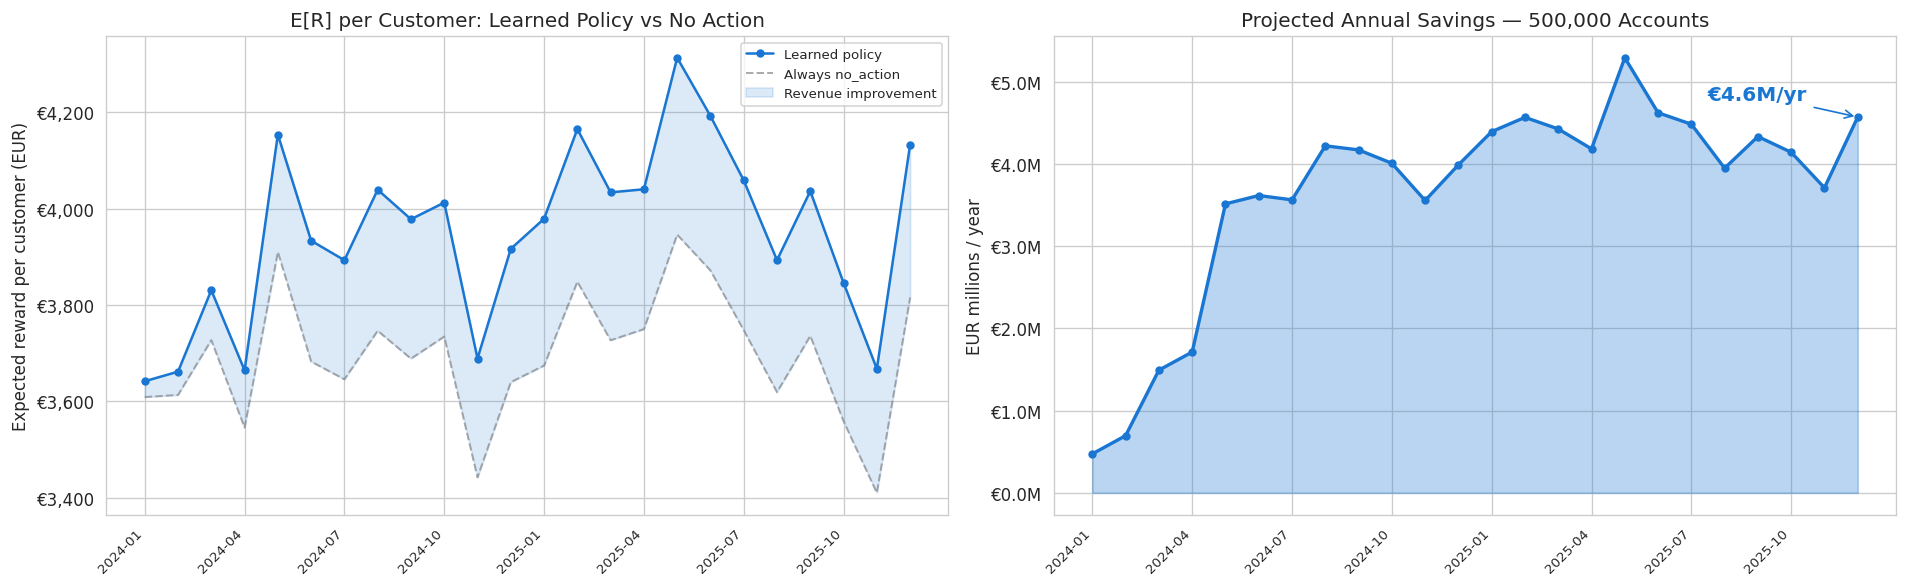

Scaling: simulation → production
  Sim avg value: €5,181/yr  →  Real: €600/yr (×0.116)
  Sim avg churn: 32%         →  Real: 8% (×0.25)
  Combined realism scale: 0.0289

Projection for 500,000 accounts:
  Final annual savings rate (month 24):   €4,570,009
  Steady-state annual savings (avg m13-24): €4,388,748
  Cumulative savings over 24 months:        €7,305,936


In [98]:
# ── Realistic production projection ──
# Scale simulation results to a Croatian bank with 500k accounts:
#   - Simulation: avg customer value €5,180/yr, avg churn ~28%
#   - Real bank:  avg customer value  ~€600/yr, avg churn ~8%
sim_avg_value = df["customer_value_score"].mean()
sim_avg_churn = df["churn_risk_score"].mean()

REAL_AVG_REVENUE = 600    # EUR/customer/year (Croatian retail bank estimate)
REAL_CHURN_RATE = 0.08    # ~8% annual churn rate

value_scale = REAL_AVG_REVENUE / sim_avg_value
churn_scale = REAL_CHURN_RATE / sim_avg_churn
realism_scale = value_scale * churn_scale

# "If deployed today with 500k accounts, what annual savings does this month's model generate?"
mdf["projected_annual_savings_500k"] = (
    mdf["improvement_vs_noaction"] * realism_scale * BANK_ACCOUNTS
)
# Monthly incremental savings (annual rate / 12)
mdf["monthly_savings_500k"] = mdf["projected_annual_savings_500k"] / 12
mdf["cumul_savings_500k"] = mdf["monthly_savings_500k"].cumsum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

month_labels = [pd.Timestamp(r.month).strftime("%Y-%m") for _, r in mdf.iterrows()]
tick_step = 3

# ── Left: E[R] policy vs no_action over time ──
ax1 = axes[0]
ax1.plot(range(len(mdf)), mdf["policy_er"], "o-", color="#1976D2",
         markersize=4, linewidth=1.5, label="Learned policy", zorder=3)
ax1.plot(range(len(mdf)), mdf["noaction_er"], "--", color="#888",
         linewidth=1.2, alpha=0.7, label="Always no_action")
ax1.fill_between(range(len(mdf)), mdf["noaction_er"], mdf["policy_er"],
                 where=mdf["policy_er"] > mdf["noaction_er"],
                 alpha=0.15, color="#1976D2", label="Revenue improvement")
ax1.set_xticks(range(0, len(mdf), tick_step))
ax1.set_xticklabels([month_labels[i] for i in range(0, len(mdf), tick_step)],
                    rotation=45, ha="right", fontsize=8)
ax1.set_ylabel("Expected reward per customer (EUR)")
ax1.set_title("E[R] per Customer: Learned Policy vs No Action")
ax1.legend(fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))

# ── Right: Projected annual savings rate for 500k accounts ──
ax2 = axes[1]
ax2.fill_between(range(len(mdf)), 0, mdf["projected_annual_savings_500k"] / 1e6,
                 alpha=0.3, color="#1976D2")
ax2.plot(range(len(mdf)), mdf["projected_annual_savings_500k"] / 1e6, "o-",
         color="#1976D2", markersize=4, linewidth=2)
ax2.set_xticks(range(0, len(mdf), tick_step))
ax2.set_xticklabels([month_labels[i] for i in range(0, len(mdf), tick_step)],
                    rotation=45, ha="right", fontsize=8)
ax2.set_ylabel("EUR millions / year")
ax2.set_title(f"Projected Annual Savings — {BANK_ACCOUNTS:,} Accounts")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:,.1f}M"))

# Annotate final annual rate
final_annual = mdf["projected_annual_savings_500k"].iloc[-1]
ax2.annotate(f"€{final_annual/1e6:,.1f}M/yr", xy=(len(mdf)-1, final_annual/1e6),
             xytext=(-90, 10), textcoords="offset points",
             fontsize=12, fontweight="bold", color="#1976D2",
             arrowprops=dict(arrowstyle="->", color="#1976D2"))

plt.tight_layout()
plt.savefig("../data/output/bandit_revenue_saved.png", dpi=150, bbox_inches="tight")
plt.show()

# Print projection summary
final_cumul_2yr = mdf["cumul_savings_500k"].iloc[-1]
steady_annual = mdf[mdf["month_idx"] >= 12]["projected_annual_savings_500k"].mean()

print(f"Scaling: simulation → production")
print(f"  Sim avg value: €{sim_avg_value:,.0f}/yr  →  Real: €{REAL_AVG_REVENUE}/yr (×{value_scale:.3f})")
print(f"  Sim avg churn: {sim_avg_churn:.0%}         →  Real: {REAL_CHURN_RATE:.0%} (×{churn_scale:.2f})")
print(f"  Combined realism scale: {realism_scale:.4f}")
print(f"\nProjection for {BANK_ACCOUNTS:,} accounts:")
print(f"  Final annual savings rate (month 24):   €{final_annual:,.0f}")
print(f"  Steady-state annual savings (avg m13-24): €{steady_annual:,.0f}")
print(f"  Cumulative savings over 24 months:        €{final_cumul_2yr:,.0f}")

### 4.3 Parameter dynamics (‖θ_a‖ over time)

Per Section 7: "the estimated call-model coefficients θ_{a3} should stabilize as evidence accumulates".

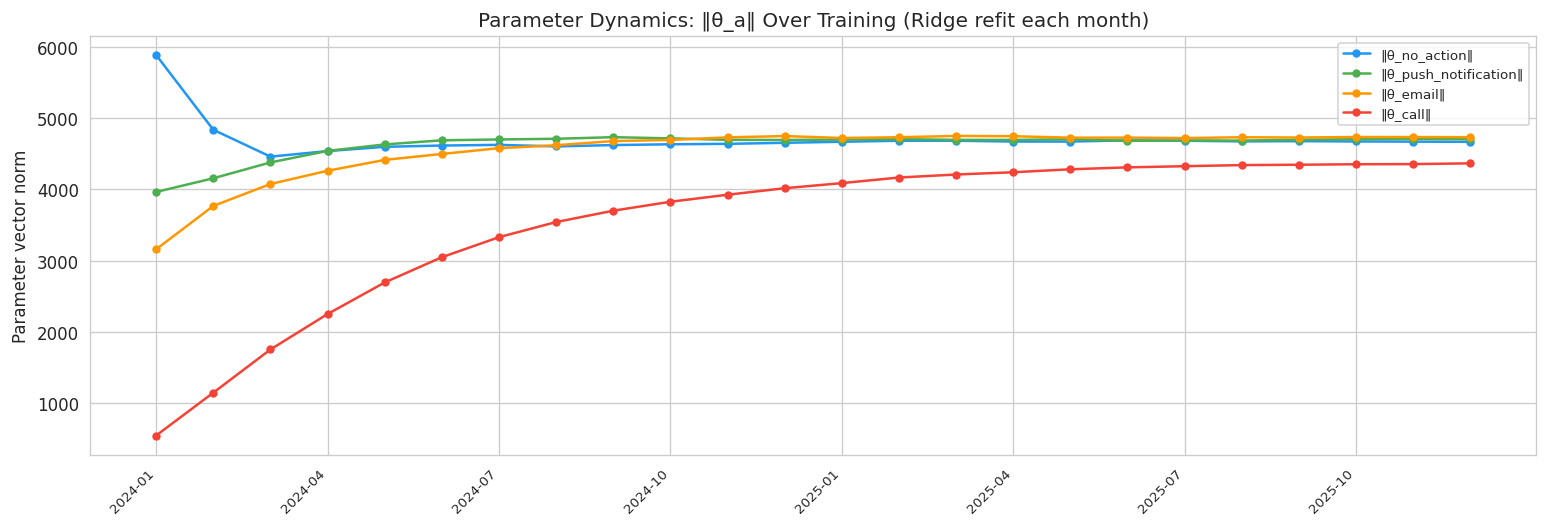

In [99]:
fig, ax = plt.subplots(figsize=(13, 4.5))

month_labels = [pd.Timestamp(r.month).strftime("%Y-%m") for _, r in mdf.iterrows()]

for a_name in ACTIONS:
    ax.plot(range(len(mdf)), mdf[f"theta_norm_{a_name}"],
            "o-", color=action_colors[a_name], markersize=4, linewidth=1.5,
            label=f"‖θ_{a_name}‖")

tick_step = 3
ax.set_xticks(range(0, len(mdf), tick_step))
ax.set_xticklabels([month_labels[i] for i in range(0, len(mdf), tick_step)],
                   rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Parameter vector norm")
ax.set_title("Parameter Dynamics: ‖θ_a‖ Over Training (Ridge refit each month)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../data/output/bandit_theta_dynamics.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Holdout Evaluation with Ground-Truth Rewards

We use the last 6 months as holdout and evaluate using the **true expected reward** $E[R(a)] = (1 - p(a)) \cdot v - c(a)$ for each action. This gives exact, unbiased policy comparison — no need for matched or IPS estimation.

In [100]:
# Use last 6 months as holdout
holdout_months = months[-6:]
holdout_mask = df["reference_date"].isin(holdout_months)
df_holdout = df[holdout_mask].reset_index(drop=True)
X_holdout = X_all[holdout_mask.values]
ER_holdout = ER_matrix[holdout_mask.values]  # ground-truth expected rewards

print(f"Holdout: {len(df_holdout):,} rows, months: {[pd.Timestamp(m).strftime('%Y-%m') for m in holdout_months]}")

# ── Learned policy actions on holdout ──
learned_actions = np.array([bandit.select_action(X_holdout[i], explore=False)
                            for i in range(len(X_holdout))])
learned_action_names = [ACTIONS[a] for a in learned_actions]

# ── Ground-truth expected reward of learned policy ──
learned_er = np.array([ER_holdout[i, learned_actions[i]] for i in range(len(df_holdout))])

print(f"\nLearned policy:")
print(f"  Avg E[R]: €{learned_er.mean():,.0f}")
for a_name in ACTIONS:
    frac = (np.array(learned_action_names) == a_name).mean()
    print(f"  {a_name}: {frac:.1%}")

Holdout: 16,386 rows, months: ['2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12']

Learned policy:
  Avg E[R]: €3,940
  no_action: 13.3%
  push_notification: 27.6%
  email: 34.0%
  call: 25.1%


In [101]:
# ── Revenue Impact: E[R] - customer_value (how much each strategy LOSES to churn + costs) ──
# This shows the NET impact: negative values = revenue lost to churn and action costs
# Less negative = better (strategy prevents more churn relative to its cost)

v_holdout = df_holdout["customer_value_score"].values  # annual customer revenue

results = {}  # Revenue Impact per customer

# Baselines: compute ER - v for each
results["Always no_action"] = (ER_holdout[:, 0] - v_holdout).mean()
results["Always push"] = (ER_holdout[:, 1] - v_holdout).mean()
results["Always email"] = (ER_holdout[:, 2] - v_holdout).mean()
results["Always call"] = (ER_holdout[:, 3] - v_holdout).mean()

# Uniform random
np.random.seed(123)
uniform_actions = np.random.randint(0, N_ACTIONS, size=len(df_holdout))
uniform_er = np.array([ER_holdout[i, uniform_actions[i]] for i in range(len(df_holdout))])
results["Uniform random"] = (uniform_er - v_holdout).mean()

# Learned policy
results["Learned policy"] = (learned_er - v_holdout).mean()

print("=" * 68)
print("  HOLDOUT: REVENUE IMPACT PER CUSTOMER (EUR)")
print("  = E[R] - customer_value  (less negative = better)")
print("=" * 68)
for name, impact in sorted(results.items(), key=lambda x: -x[1]):
    marker = " ◀ LEARNED" if name == "Learned policy" else ""
    print(f"  {name:<22s}  Impact = €{impact:>8,.0f}{marker}")
print("=" * 68)

improvement = results["Learned policy"] - results["Always no_action"]
print(f"\n  Improvement over no_action:  +€{improvement:,.0f}/customer (saves €{improvement:,.0f} more revenue)")
print(f"  Improvement over always_call: +€{results['Learned policy'] - results['Always call']:,.0f}/customer")
print(f"  Improvement over always_email: +€{results['Learned policy'] - results['Always email']:,.0f}/customer")

n_holdout = len(df_holdout)
# Production projection using realistic scaling
projected_annual_holdout = improvement * realism_scale * BANK_ACCOUNTS
print(f"\n  Production projection ({BANK_ACCOUNTS:,} accounts):")
print(f"    Annual revenue saved: €{projected_annual_holdout:,.0f}")
print(f"    2-year revenue saved: €{projected_annual_holdout * 2:,.0f}")

  HOLDOUT: REVENUE IMPACT PER CUSTOMER (EUR)
  = E[R] - customer_value  (less negative = better)
  Learned policy          Impact = €  -1,154 ◀ LEARNED
  Always email            Impact = €  -1,329
  Always push             Impact = €  -1,394
  Always no_action        Impact = €  -1,446
  Uniform random          Impact = €  -1,451
  Always call             Impact = €  -1,634

  Improvement over no_action:  +€292/customer (saves €292 more revenue)
  Improvement over always_call: +€480/customer
  Improvement over always_email: +€175/customer

  Production projection (500,000 accounts):
    Annual revenue saved: €4,218,085
    2-year revenue saved: €8,436,170


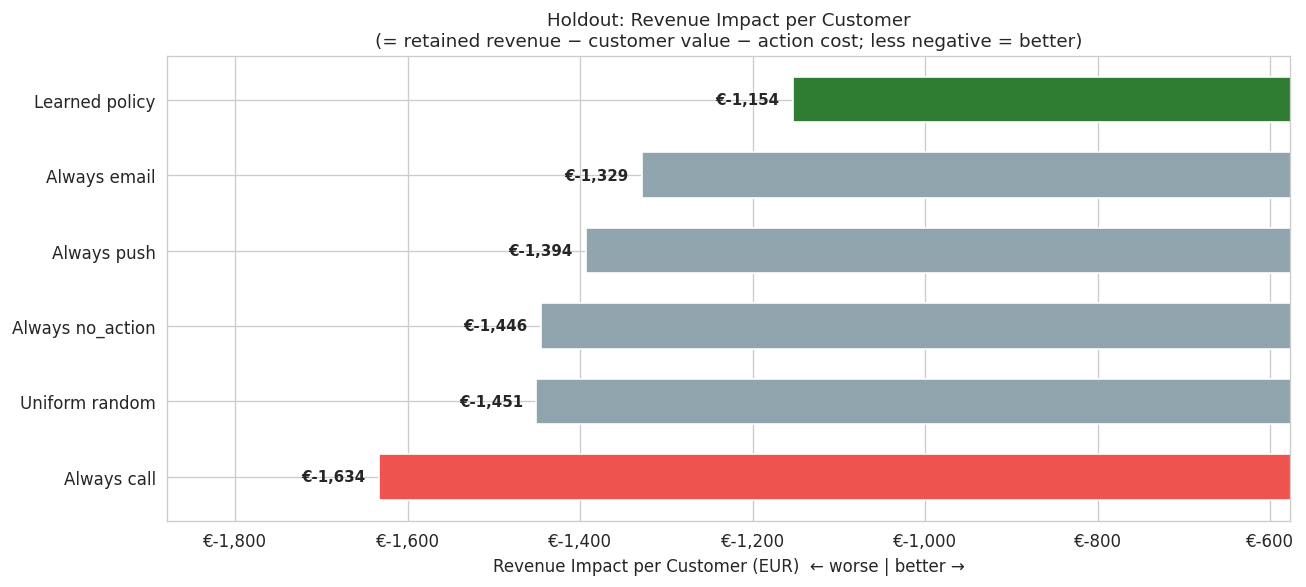

In [102]:
# ── Visual: Revenue Impact per Customer ──
fig, ax = plt.subplots(figsize=(11, 5))

# Sort by impact (best at top)
sorted_results = sorted(results.items(), key=lambda x: x[1])
names = [r[0] for r in sorted_results]
impacts = [r[1] for r in sorted_results]

colors = ['#2E7D32' if n == "Learned policy" else
          '#EF5350' if n == "Always call" else
          '#90A4AE' for n in names]

bars = ax.barh(names, impacts, color=colors, edgecolor="white", height=0.6)

# Zero line
ax.axvline(0, color="#333", linewidth=1.2)

for bar, val in zip(bars, impacts):
    # Put label at the end of each bar
    offset = -15 if val < 0 else 15
    ha = "right" if val < 0 else "left"
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f"€{val:,.0f}", va="center", ha=ha, fontsize=9, fontweight="bold")

ax.set_xlabel("Revenue Impact per Customer (EUR)  ← worse | better →")
ax.set_title("Holdout: Revenue Impact per Customer\n(= retained revenue − customer value − action cost; less negative = better)",
             fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
ax.set_xlim(min(impacts) * 1.15, max(impacts) * 0.5)

plt.tight_layout()
plt.savefig("../data/output/bandit_policy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.1 Learned action mix by customer value decile

Per Section 7: "call selection probability increases with expected value/uplift, not uniformly for all customers"

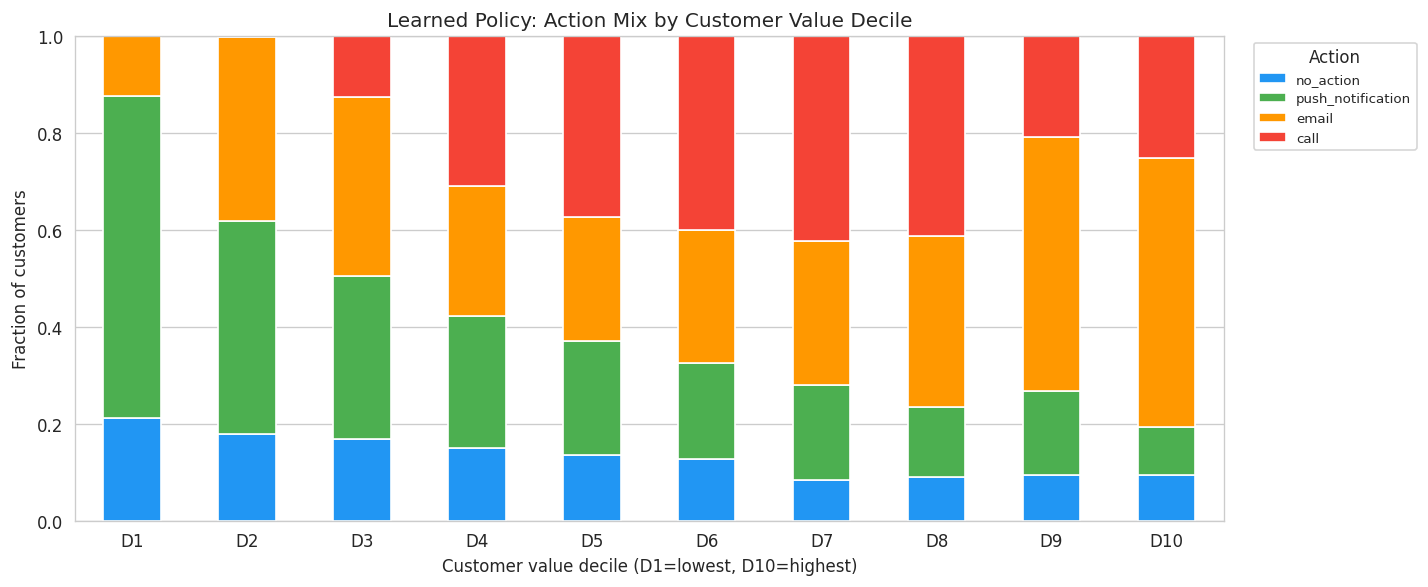


Action fractions by value decile:
learned_action  no_action  push_notification  email   call
value_decile                                              
D1                  0.212              0.664  0.124  0.000
D2                  0.179              0.439  0.379  0.003
D3                  0.169              0.336  0.369  0.126
D4                  0.149              0.273  0.268  0.309
D5                  0.135              0.235  0.256  0.374
D6                  0.127              0.198  0.275  0.400
D7                  0.085              0.195  0.298  0.422
D8                  0.091              0.143  0.353  0.413
D9                  0.094              0.173  0.526  0.208
D10                 0.093              0.100  0.556  0.251

Call fraction D1=0.000, D10=0.251 → ✓ Calls increase with value


In [103]:
# Build evaluation DataFrame
df_eval = df_holdout.copy()
df_eval["learned_action"] = learned_action_names
df_eval["learned_er"] = learned_er

# Value decile analysis
df_eval["value_decile"] = pd.qcut(df_eval["customer_value_score"], 10,
                                   labels=[f"D{i}" for i in range(1, 11)])

action_by_value = pd.crosstab(df_eval["value_decile"], df_eval["learned_action"],
                               normalize="index")[ACTIONS]

fig, ax = plt.subplots(figsize=(12, 5))
action_by_value.plot(kind="bar", stacked=True, ax=ax,
                      color=[action_colors[a] for a in ACTIONS])
ax.set_ylabel("Fraction of customers")
ax.set_xlabel("Customer value decile (D1=lowest, D10=highest)")
ax.set_title("Learned Policy: Action Mix by Customer Value Decile")
ax.legend(title="Action", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig("../data/output/bandit_actions_by_value.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nAction fractions by value decile:")
print(action_by_value.round(3).to_string())

# Key check: calls should increase with value
call_d1 = action_by_value.loc["D1", "call"]
call_d10 = action_by_value.loc["D10", "call"]
print(f"\nCall fraction D1={call_d1:.3f}, D10={call_d10:.3f} → {'✓ Calls increase with value' if call_d10 > call_d1 else '✗ Issue'}")

### 5.2 Learned action mix by churn risk decile

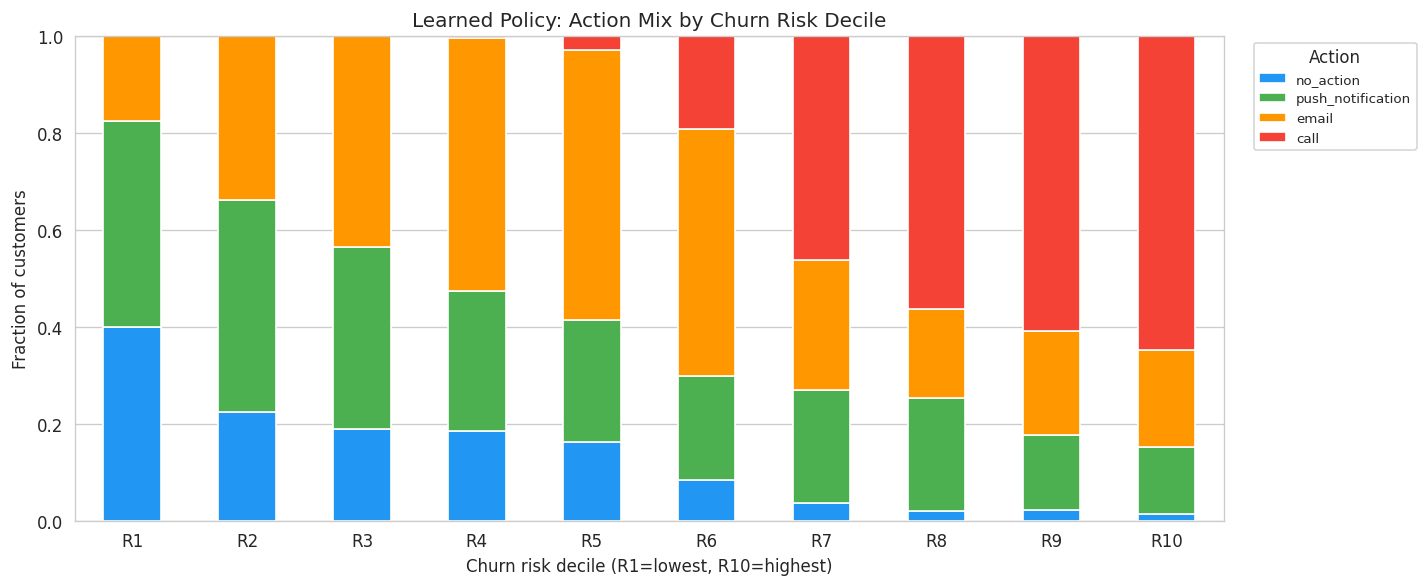


Action fractions by risk decile:
learned_action  no_action  push_notification  email   call
risk_decile                                               
R1                  0.399              0.425  0.176  0.000
R2                  0.223              0.439  0.337  0.001
R3                  0.190              0.375  0.435  0.000
R4                  0.185              0.289  0.522  0.004
R5                  0.162              0.252  0.557  0.029
R6                  0.084              0.215  0.511  0.191
R7                  0.036              0.233  0.270  0.462
R8                  0.020              0.234  0.182  0.564
R9                  0.022              0.156  0.214  0.609
R10                 0.013              0.138  0.200  0.649


In [104]:
df_eval["risk_decile"] = pd.qcut(df_eval["churn_risk_score"], 10,
                                 labels=[f"R{i}" for i in range(1, 11)], duplicates="drop")

action_by_risk = pd.crosstab(df_eval["risk_decile"], df_eval["learned_action"],
                              normalize="index")[ACTIONS]

fig, ax = plt.subplots(figsize=(12, 5))
action_by_risk.plot(kind="bar", stacked=True, ax=ax,
                     color=[action_colors[a] for a in ACTIONS])
ax.set_ylabel("Fraction of customers")
ax.set_xlabel("Churn risk decile (R1=lowest, R10=highest)")
ax.set_title("Learned Policy: Action Mix by Churn Risk Decile")
ax.legend(title="Action", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig("../data/output/bandit_actions_by_risk.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nAction fractions by risk decile:")
print(action_by_risk.round(3).to_string())

### 5.3 Call probability heatmap: Risk × Value

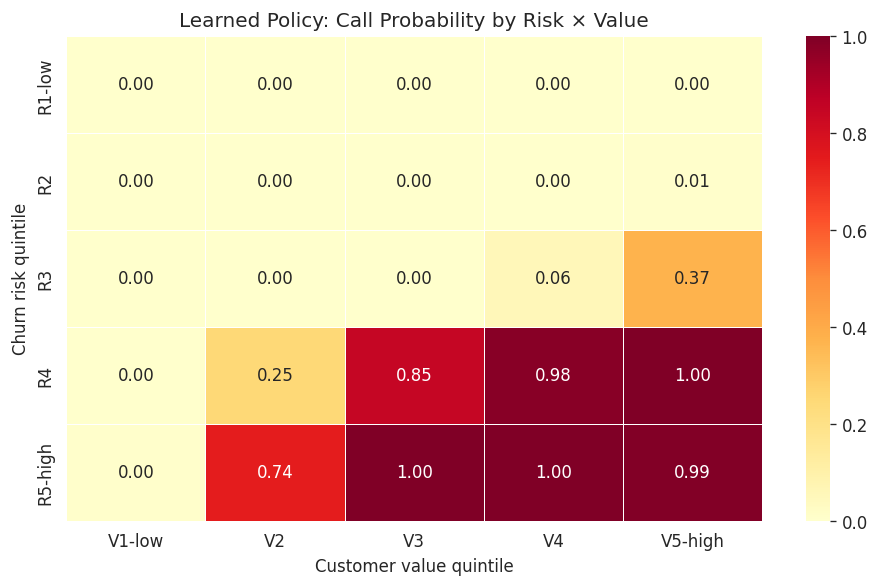

In [105]:
# Call probability by risk × value quintile
df_eval["is_call"] = (df_eval["learned_action"] == "call").astype(int)
df_eval["value_q5"] = pd.qcut(df_eval["customer_value_score"], 5,
                                labels=["V1-low","V2","V3","V4","V5-high"])
df_eval["risk_q5"] = pd.qcut(df_eval["churn_risk_score"], 5,
                               labels=["R1-low","R2","R3","R4","R5-high"],
                               duplicates="drop")

call_heatmap = df_eval.pivot_table("is_call", index="risk_q5", columns="value_q5",
                                    aggfunc="mean")

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(call_heatmap, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax,
            vmin=0, vmax=1, linewidths=0.5)
ax.set_title("Learned Policy: Call Probability by Risk × Value")
ax.set_ylabel("Churn risk quintile")
ax.set_xlabel("Customer value quintile")
plt.tight_layout()
plt.savefig("../data/output/bandit_call_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Learning Progression: Snapshots Over Time

Compare policy snapshots at three stages:
1. **Month 3** (early learning) — model has seen very little data
2. **Month 12** (mid-training) — model has accumulated a year of data
3. **Month 24** (fully trained) — model has converged

In [106]:
# ── Re-train with snapshots at stages ──
import copy
np.random.seed(SEED)
stage_bandits = {}
SNAPSHOT_MONTHS = [3, 12, 24]  # Early, mid, fully trained

bandit_staged = RidgeContextualBandit(
    n_actions=N_ACTIONS, d=d, alpha=ALPHA,
    epsilon=EPSILON_START, epsilon_decay=EPSILON_DECAY, epsilon_min=EPSILON_MIN,
    action_costs=[ACTION_COSTS[a] for a in ACTIONS],
    cost_reg_scale=COST_REG_SCALE, cost_reg_decay=COST_REG_DECAY,
)

for month_idx, month in enumerate(months):
    batch_mask = df["reference_date"] == month
    batch_indices = df.index[batch_mask].values
    
    X_batch = X_all[batch_indices]
    a_batch = np.array([ACTION_TO_IDX[a] for a in df.loc[batch_indices, "action"]])
    r_batch = df.loc[batch_indices, "reward"].values
    
    bandit_staged.add_batch(X_batch, a_batch, r_batch)
    bandit_staged.refit()
    bandit_staged.decay_epsilon()
    bandit_staged.decay_cost_reg()
    
    if (month_idx + 1) in SNAPSHOT_MONTHS:
        stage_bandits[month_idx + 1] = copy.deepcopy(bandit_staged)
        # Evaluate on holdout
        sa = np.array([stage_bandits[month_idx+1].select_action(X_holdout[i], explore=False)
                       for i in range(len(X_holdout))])
        er = np.mean([ER_holdout[i, sa[i]] for i in range(len(df_holdout))])
        print(f"Snapshot month {month_idx+1}: E[R]=€{er:,.0f}, "
              f"call frac={(sa == 3).mean():.1%}, "
              f"α_call={bandit_staged.alpha + bandit_staged.cost_reg_scale * ACTION_COSTS['call']:,.0f}")

print(f"\nSnapshots saved at months: {list(stage_bandits.keys())}")

Snapshot month 3: E[R]=€3,729, call frac=1.1%, α_call=1,844
Snapshot month 12: E[R]=€3,931, call frac=22.2%, α_call=248
Snapshot month 24: E[R]=€3,940, call frac=25.1%, α_call=18

Snapshots saved at months: [3, 12, 24]


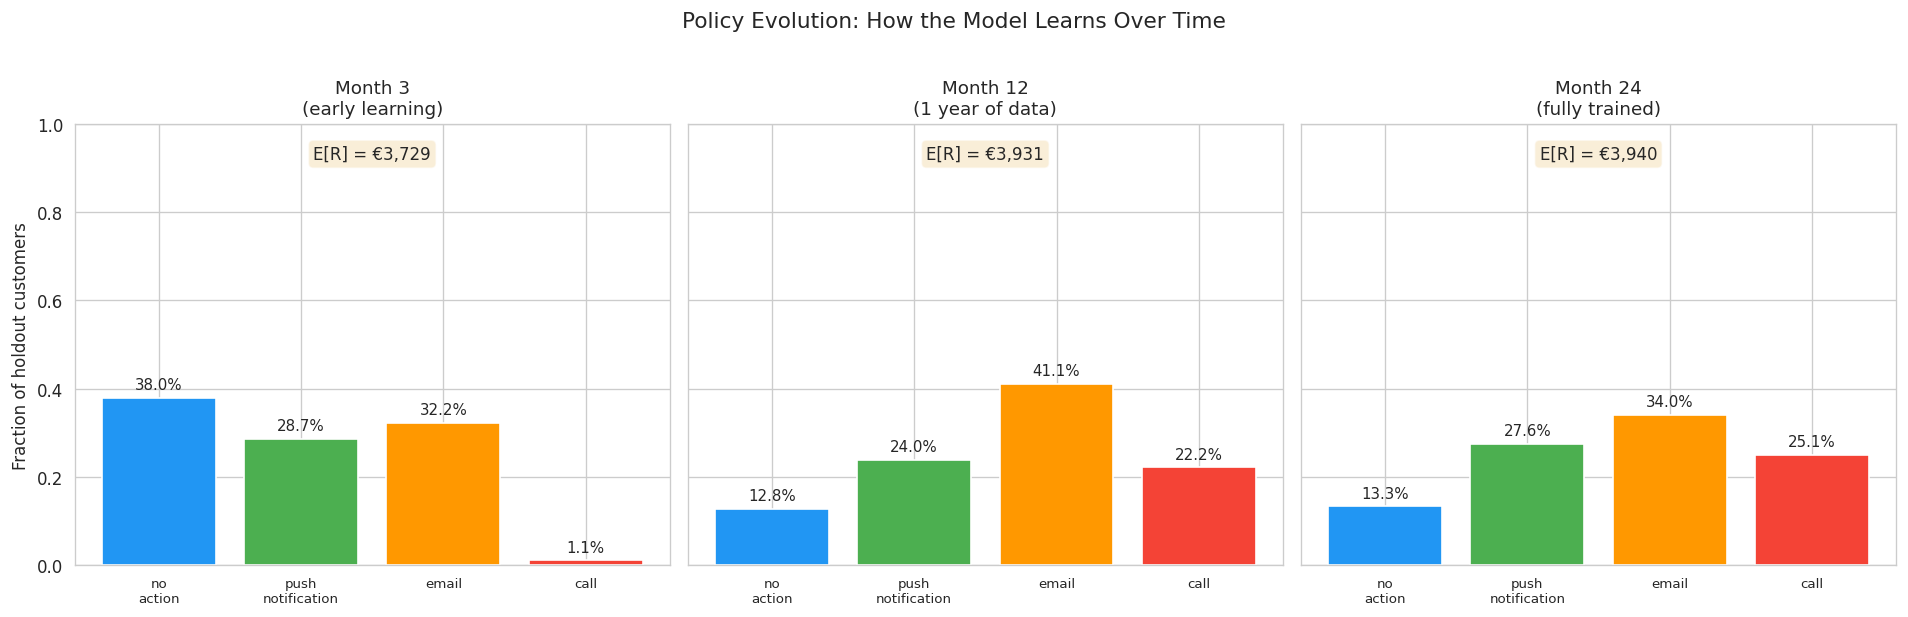

In [107]:
# ── Compare policies at each stage on holdout ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

stage_labels = {3: "Month 3\n(early learning)", 
                12: "Month 12\n(1 year of data)",
                24: "Month 24\n(fully trained)"}

for ax_idx, (stage_month, stage_bandit) in enumerate(sorted(stage_bandits.items())):
    ax = axes[ax_idx]
    
    stage_actions = np.array([stage_bandit.select_action(X_holdout[i], explore=False)
                              for i in range(len(X_holdout))])
    stage_action_names = [ACTIONS[a] for a in stage_actions]
    
    counts = pd.Series(stage_action_names).value_counts().reindex(ACTIONS, fill_value=0)
    fracs = counts / counts.sum()
    
    bars = ax.bar(range(N_ACTIONS), fracs, color=[action_colors[a] for a in ACTIONS])
    ax.set_title(stage_labels[stage_month], fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_xticks(range(N_ACTIONS))
    ax.set_xticklabels([a.replace("_", "\n") for a in ACTIONS], fontsize=8)
    if ax_idx == 0:
        ax.set_ylabel("Fraction of holdout customers")
    
    for bar, frac in zip(bars, fracs):
        if frac > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f"{frac:.1%}", ha="center", fontsize=9)
    
    # Ground-truth expected reward
    er = np.mean([ER_holdout[i, stage_actions[i]] for i in range(len(df_holdout))])
    ax.text(0.5, 0.92, f"E[R] = €{er:,.0f}",
            transform=ax.transAxes, ha="center", fontsize=10,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

fig.suptitle("Policy Evolution: How the Model Learns Over Time", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../data/output/bandit_policy_evolution.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Summary statistics and final diagnostics

In [108]:
print("═" * 70)
print("  MODEL 2: CONTEXTUAL BANDIT — LEARNING SUMMARY")
print("═" * 70)

print(f"\n  Architecture:    Ridge reward model, θ_a ∈ R^{d} per action")
print(f"  Actions:         {ACTIONS}")
print(f"  Costs (EUR):     {ACTION_COSTS}")
print(f"  Ridge α_base:    {ALPHA}")
print(f"  Cost-aware reg:  scale₀={COST_REG_SCALE}, decay={COST_REG_DECAY}")
print(f"  ε schedule:      {EPSILON_START} → {bandit.epsilon:.4f}")
print(f"  Training:        {len(months)} months, cumulative refit each month")
print(f"  Samples/action:  {dict(zip(ACTIONS, bandit.n_samples.astype(int)))}")

print(f"\n  ── Holdout: Revenue Impact per Customer (EUR) ──")
print(f"    (= E[R] − customer_value; less negative = better)")
for name, impact in sorted(results.items(), key=lambda x: -x[1]):
    marker = " ◀" if name == "Learned policy" else ""
    print(f"    {name:<22s}  Impact = €{impact:>8,.0f}{marker}")

improvement = results["Learned policy"] - results["Always no_action"]
print(f"\n  ── Key metrics ──")
print(f"    Beats 'always no_action'?  {'✓ YES' if improvement > 0 else '✗ NO'} (+€{improvement:,.0f})")
print(f"    Beats 'always call'?       {'✓ YES' if results['Learned policy'] > results['Always call'] else '✗ NO'}")
print(f"    Beats 'always email'?      {'✓ YES' if results['Learned policy'] > results['Always email'] else '✗ NO'}")
print(f"    Beats 'uniform random'?    {'✓ YES' if results['Learned policy'] > results['Uniform random'] else '✗ NO'}")

print(f"\n  ── Learning progression ──")
early_call = mdf[mdf["month_idx"] < 6]["frac_call"].mean()
late_call = mdf[mdf["month_idx"] >= 18]["frac_call"].mean()
print(f"    Call fraction (months 1-6):   {early_call:.1%}  (model is conservative)")
print(f"    Call fraction (months 19-24): {late_call:.1%}  (model has learned)")

print(f"\n  ── Call targeting ──")
call_d1 = action_by_value.loc["D1", "call"] if "D1" in action_by_value.index else 0
call_d10 = action_by_value.loc["D10", "call"] if "D10" in action_by_value.index else 0
call_r1 = action_by_risk.loc["R1", "call"] if "R1" in action_by_risk.index else 0
call_r10 = action_by_risk.loc["R10", "call"] if "R10" in action_by_risk.index else 0
print(f"    Call D1 (lowest value):  {call_d1:.1%}   D10 (highest): {call_d10:.1%}  → {'✓' if call_d10 > call_d1 else '✗'} calls ↑ with value")
print(f"    Call R1 (lowest risk):   {call_r1:.1%}   R10 (highest): {call_r10:.1%}  → {'✓' if call_r10 > call_r1 else '✗'} calls ↑ with risk")

print(f"\n  ── Policy evolution ──")
for sm, sb in sorted(stage_bandits.items()):
    sa = np.array([sb.select_action(X_holdout[i], explore=False) for i in range(len(X_holdout))])
    er = np.mean([ER_holdout[i, sa[i]] for i in range(len(df_holdout))])
    call_frac = (sa == 3).mean()
    print(f"    Month {sm:>2}: E[R]=€{er:,.0f}, call={call_frac:.1%}")

print(f"\n  ── Revenue projection ({BANK_ACCOUNTS:,} accounts, Croatian bank) ──")
steady_annual = mdf[mdf["month_idx"] >= 12]["projected_annual_savings_500k"].mean()
final_cumul_2yr = mdf["cumul_savings_500k"].iloc[-1]
print(f"    Steady-state annual savings:  €{steady_annual:,.0f}")
print(f"    Cumulative (24 months):       €{final_cumul_2yr:,.0f}")
print(f"    (Scaled: avg revenue €{REAL_AVG_REVENUE}/customer/yr, {REAL_CHURN_RATE:.0%} churn)")

print("\n" + "═" * 70)

══════════════════════════════════════════════════════════════════════
  MODEL 2: CONTEXTUAL BANDIT — LEARNING SUMMARY
══════════════════════════════════════════════════════════════════════

  Architecture:    Ridge reward model, θ_a ∈ R^24 per action
  Actions:         ['no_action', 'push_notification', 'email', 'call']
  Costs (EUR):     {'no_action': 0.0, 'push_notification': 20.0, 'email': 100.0, 'call': 1200.0}
  Ridge α_base:    1.0
  Cost-aware reg:  scale₀=3.0, decay=0.8
  ε schedule:      0.25 → 0.0200
  Training:        24 months, cumulative refit each month
  Samples/action:  {'no_action': np.int64(13133), 'push_notification': np.int64(14598), 'email': np.int64(22552), 'call': np.int64(15261)}

  ── Holdout: Revenue Impact per Customer (EUR) ──
    (= E[R] − customer_value; less negative = better)
    Learned policy          Impact = €  -1,154 ◀
    Always email            Impact = €  -1,329
    Always push             Impact = €  -1,394
    Always no_action        Impact = 